In [1]:
# Cell 1: 只加载 overlay，不加载 xmodel
import sys
sys.path.append('/usr/lib/python3/site-packages')
import os, numpy as np
sys.path.insert(0, '/home/xilinx/jupyter_notebooks/soft/DPU-PYNQ')
from pynq_dpu import DpuOverlay

WORK_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae'
overlay = DpuOverlay(os.path.join(WORK_DIR, 'pl_vq_31ms_260422/dpu.bit'))
print("✅ Overlay OK")

✅ Overlay OK


In [2]:
# 查看是否能看到 vq_accel_1
print(overlay.ip_dict.keys())

# 检查 vq_accel 的寄存器映射
vq_ip = overlay.vq_accel_1
print(vq_ip.register_map)

dict_keys(['axi_intc_0', 'DPUCZDX8G_1', 'vq_accel_1', 'ps_e'])
RegisterMap {
  CTRL = Register(AP_START=0, AP_DONE=0, AP_IDLE=1, AP_READY=0, AP_CONTINUE=0, RESERVED_1=0, AUTO_RESTART=0, RESERVED_2=0, INTERRUPT=0, RESERVED_3=0),
  GIER = Register(Enable=0, RESERVED=0),
  IP_IER = Register(CHAN0_INT_EN=0, CHAN1_INT_EN=0, RESERVED_0=0),
  IP_ISR = Register(CHAN0_INT_ST=0, CHAN1_INT_ST=0, RESERVED_0=0),
  in_z_1 = Register(in_z=write-only),
  in_z_2 = Register(in_z=write-only),
  in_codebook_1 = Register(in_codebook=write-only),
  in_codebook_2 = Register(in_codebook=write-only),
  out_z_q_1 = Register(out_z_q=write-only),
  out_z_q_2 = Register(out_z_q=write-only),
  enc_scale_fp = Register(enc_scale_fp=write-only),
  dec_scale_inv_fp = Register(dec_scale_inv_fp=write-only)
}


In [3]:
# Cell 2: 只加载 Encoder，不运行推理
import vart, xir

def get_dpu_subgraph(xmodel_path):
    graph = xir.Graph.deserialize(xmodel_path)
    root = graph.get_root_subgraph()
    children = root.toposort_child_subgraph()
    dpu_subgraphs = [s for s in children
                     if s.has_attr("device") and s.get_attr("device").upper() == "DPU"]
    return graph, dpu_subgraphs[0]

enc_graph, enc_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'xmodel/encoder_zcu111_700x500_old.xmodel'))
enc_runner = vart.Runner.create_runner(enc_subgraph, "run")
enc_in_tensors  = enc_runner.get_input_tensors()
enc_out_tensors = enc_runner.get_output_tensors()
print("✅ Encoder runner OK")
print(f"   输入 shape: {tuple(enc_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(enc_out_tensors[0].dims)}")

✅ Encoder runner OK
   输入 shape: (1, 500, 700, 3)
   输出 shape: (1, 125, 175, 64)


In [4]:
# Cell 3: 只做 fix_point，不运行推理
def get_fixpoint_scale(tensors):
    scales = []
    for t in tensors:
        try:
            fp = t.get_attr("fix_point")
            scales.append(2 ** (-fp))
            print(f"  {t.name}: fix_point={fp}, scale={2**(-fp):.6f}")
        except:
            scales.append(1.0)
            print(f"  {t.name}: 无fix_point, scale=1.0")
    return scales

enc_in_scales  = get_fixpoint_scale(enc_in_tensors)
enc_out_scales = get_fixpoint_scale(enc_out_tensors)
print("✅ fix_point OK")

  EncoderWrapper__input_0_fix: fix_point=6, scale=0.015625
  EncoderWrapper__EncoderWrapper_Conv2d_pre_quantization_conv__ret_fix: fix_point=6, scale=0.015625
✅ fix_point OK


In [5]:
# # Cell 4: 只做图片预处理
# import cv2
# img_bgr = cv2.imread(os.path.join(WORK_DIR, 'img.png'))
# # img_bgr = cv2.imread(os.path.join(WORK_DIR, 'test2.jpg'))
# img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# img_small = cv2.resize(img_rgb, (700,500), interpolation=cv2.INTER_LINEAR)
# input_fp32 = (img_small.astype(np.float32)/255.0 - 0.5) / 0.5
# input_fp32 = input_fp32[np.newaxis]
# print(f"✅ 预处理 OK, shape={input_fp32.shape}")

# Cell 4: 只做图片预处理（改用 PIL BILINEAR，和 main.py/transforms.Resize 一致）
from PIL import Image as PILImage

img_pil    = PILImage.open(os.path.join(WORK_DIR, 'img.png')).convert('RGB')
img_small  = img_pil.resize((700, 500), PILImage.BILINEAR)          # 和 transforms.Resize 一致
# img_arr    = np.array(img_small).astype(np.float32)                  # uint8 -> float32
img_arr = np.asarray(img_small, dtype=np.float32)
input_fp32 = (img_arr / 255.0 - 0.5) / 0.5                          # 归一化到 [-1,1]
input_fp32 = input_fp32[np.newaxis]                                  # (1,500,700,3)
print(f"✅ 预处理 OK, shape={input_fp32.shape}")

✅ 预处理 OK, shape=(1, 500, 700, 3)


In [6]:
# Cell 5: 只准备 buffer，不执行 execute_async
enc_input_shape  = tuple(enc_in_tensors[0].dims)
enc_output_shape = tuple(enc_out_tensors[0].dims)
enc_in_buf  = [np.empty(enc_input_shape,  dtype=np.int8, order='C')]
enc_out_buf = [np.empty(enc_output_shape, dtype=np.int8, order='C')]
enc_in_buf[0][...] = np.clip(
    np.round(input_fp32 / enc_in_scales[0]), -128, 127
).astype(np.int8)
print(f"✅ Buffer 准备 OK")
print(f"   enc_in_buf  dtype={enc_in_buf[0].dtype}, shape={enc_in_buf[0].shape}")
print(f"   enc_out_buf dtype={enc_out_buf[0].dtype}, shape={enc_out_buf[0].shape}")

✅ Buffer 准备 OK
   enc_in_buf  dtype=int8, shape=(1, 500, 700, 3)
   enc_out_buf dtype=int8, shape=(1, 125, 175, 64)


In [7]:
import time
# Cell 6: 执行encoder，单独执行
print("执行前...")
start_time = time.time() # 记录开始时间

job_id = enc_runner.execute_async(enc_in_buf, enc_out_buf)
enc_runner.wait(job_id)

end_time = time.time()   # 记录结束时间
duration_ms = (end_time - start_time) * 1000
print(f"✅ Encoder 推理完成！耗时: {duration_ms:.2f} ms")

执行前...
✅ Encoder 推理完成！耗时: 24.46 ms


In [8]:
# Cell 7: 加载 Decoder runner
dec_graph, dec_subgraph = get_dpu_subgraph(
    os.path.join(WORK_DIR, 'xmodel/decoder_zcu111_700x500_old.xmodel'))
dec_runner = vart.Runner.create_runner(dec_subgraph, "run")
dec_in_tensors  = dec_runner.get_input_tensors()
dec_out_tensors = dec_runner.get_output_tensors()
dec_in_scales  = get_fixpoint_scale(dec_in_tensors)
dec_out_scales = get_fixpoint_scale(dec_out_tensors)
print("✅ Decoder runner OK")
print(f"   输入 shape: {tuple(dec_in_tensors[0].dims)}")
print(f"   输出 shape: {tuple(dec_out_tensors[0].dims)}")

  DecoderWrapper__input_0_fix: fix_point=5, scale=0.031250
  DecoderWrapper__DecoderWrapper_Decoder_decoder__Sequential_inverse_conv_stack__ConvTranspose2d_4__ret_fix: fix_point=7, scale=0.007812
✅ Decoder runner OK
   输入 shape: (1, 125, 175, 64)
   输出 shape: (1, 500, 700, 3)


In [9]:
# # Cell 8: 终极优化版 - Numba JIT 加速 VectorQuantizer
# import os, time
# import numpy as np
# from numba import njit, prange, config

# # 强制 Numba 使用 workqueue (在 ARM 上通常比 TBB 更稳定)
# config.THREADING_LAYER = 'workqueue' 

# # 1. 终极 VQ 函数：增加循环展开和局部变量缓存
# @njit(parallel=True, fastmath=True, cache=True)
# def numba_argmin_vq_ultra(z_flat, codebook):
#     num_z = z_flat.shape[0]    # 21875
#     num_c = codebook.shape[0]  # 512
#     dim   = 64                 # 固定的 C=64
    
#     indices = np.empty(num_z, dtype=np.int64)
    
#     for i in prange(num_z):
#         min_dist = 1e18
#         best_idx = 0
        
#         # 预取当前 z 向量到局部缓存（加速访问）
#         current_z = z_flat[i]
        
#         for j in range(num_c):
#             d = 0.0
#             cb_vec = codebook[j]
#             # 这里的循环会被 Numba 尝试向量化优化
#             for k in range(dim):
#                 diff = current_z[k] - cb_vec[k]
#                 d += diff * diff
            
#             if d < min_dist:
#                 min_dist = d
#                 best_idx = j
#         indices[i] = best_idx
#     return indices

# # 2. 准备数据 (确保是 C 连续的 float32)
# enc_out_scale = enc_out_scales[0]
# z_e = enc_out_buf[0].astype(np.float32) * enc_out_scale
# codebook = np.load(os.path.join(WORK_DIR, 'codebook.npy')).astype(np.float32)
# z_flat_input = np.ascontiguousarray(z_e.reshape(-1, 64))
# codebook = np.ascontiguousarray(codebook)

# print(f"✅ 线程层设置为: {config.THREADING_LAYER}")
# print("正在执行终极预热与并行计算...")

# # 预热
# _ = numba_argmin_vq_ultra(z_flat_input[:1], codebook)

# start_time = time.time()
# # --- 执行 ---
# indices_flat = numba_argmin_vq_ultra(z_flat_input, codebook)
# z_q_flat = codebook[indices_flat]
# # ------------
# duration_ms = (time.time() - start_time) * 1000

# # 恢复维度
# z_q = z_q_flat.reshape(z_e.shape)
# indices = indices_flat.reshape(z_e.shape[1], z_e.shape[2])

# print(f'🚀 终极优化后耗时: {duration_ms:.2f} ms')

In [10]:
import numpy as np
from pynq import allocate
import struct

# 1. 准备 Buffer (与 C++ 里的 depth 对应)
num_vectors = 125 * 175  # 21875
dim = 64                 # 64 floats per vector

# 分配三个独立的 Buffer，对应 gmem0, gmem1, gmem2
# in_z 使用 int8 (DPU 输出直接对接)
vq_in_z = allocate(shape=(num_vectors, dim), dtype=np.int8, cacheable=0)
# codebook 使用 float32
vq_in_codebook = allocate(shape=(512, 64), dtype=np.float32, cacheable=0)
# out_z_q 使用 int8 (对接 Decoder 输入)
vq_out_zq = allocate(shape=(num_vectors, dim), dtype=np.int8, cacheable=0)

# 2. 填充数据
# 加载 Codebook 并写入
cb_data = np.load(os.path.join(WORK_DIR, 'codebook.npy')).astype(np.float32)
vq_in_codebook[:] = cb_data
vq_in_codebook.sync_to_device()

# 写入来自 DPU Encoder 的数据
vq_in_z[:] = enc_out_buf[0].reshape(num_vectors, dim)
vq_in_z.sync_to_device()

# 3. 配置寄存器地址 (处理 64 位地址)
# in_z -> gmem0
vq_ip.register_map.in_z_1 = vq_in_z.device_address & 0xFFFFFFFF
vq_ip.register_map.in_z_2 = vq_in_z.device_address >> 32

# in_codebook -> gmem1
vq_ip.register_map.in_codebook_1 = vq_in_codebook.device_address & 0xFFFFFFFF
vq_ip.register_map.in_codebook_2 = vq_in_codebook.device_address >> 32

# out_z_q -> gmem2
vq_ip.register_map.out_z_q_1 = vq_out_zq.device_address & 0xFFFFFFFF
vq_ip.register_map.out_z_q_2 = vq_out_zq.device_address >> 32

# 4. 配置 Scale 参数 (float 转换)
# 使用 struct.unpack 将 float 转为 int32 二进制位，写入寄存器
# 1. 定义通过 MMIO 写入浮点数的函数
def write_float_to_mmio(ip, offset, val):
    # 将 float 转为 IEEE 754 标准的 4 字节整数
    float_hex = struct.unpack('<I', struct.pack('<f', float(val)))[0]
    # 使用底层 mmio 接口直接写入地址偏移
    ip.mmio.write(offset, float_hex)

# 2. 获取参数
e_scale = enc_out_scales[0]
d_scale_inv = 1.0 / dec_in_scales[0]

# 3. 按照 HLS 报告中的 Offset 写入
# enc_scale 对应 Offset 0x34
write_float_to_mmio(vq_ip, 0x34, e_scale)
# dec_scale_inv 对应 Offset 0x3c
write_float_to_mmio(vq_ip, 0x3c, d_scale_inv)

print(f"✅ Scale 参数写入成功: enc_scale={e_scale}, dec_scale_inv={d_scale_inv}")

# 5. 启动硬件
print("🚀 VQ 加速器启动...")
start_time = time.time()

vq_ip.register_map.CTRL.AP_START = 1
while not vq_ip.register_map.CTRL.AP_DONE:
    pass

duration = (time.time() - start_time) * 1000
print(f"✅ VQ 硬件推理完成！耗时: {duration:.2f} ms")

# 6. 获取结果
vq_out_zq.sync_from_device()
# 将结果重塑回 DPU Decoder 需要的形状 (1, 125, 175, 64)
z_q_hw = vq_out_zq.reshape(1, 125, 175, 64)

# 后续 Cell 9 使用 z_q_hw 即可
z_q = z_q_hw.astype(np.float32) * dec_in_scales[0]
print("z_q:")
print(z_q)

✅ Scale 参数写入成功: enc_scale=0.015625, dec_scale_inv=32.0
🚀 VQ 加速器启动...
✅ VQ 硬件推理完成！耗时: 31.47 ms
z_q:
[[[[0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   ...
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]]

  [[0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   ...
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]]

  [[0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   [0.      3.96875 3.96875 ... 3.96875 0.      3.96875]
   ...
   [0.      3.96875 3

In [11]:
# Cell 9 Decoder 推理 修复版
dec_input_shape  = tuple(dec_in_tensors[0].dims)
dec_output_shape = tuple(dec_out_tensors[0].dims)
dec_in_buf  = [np.empty(dec_input_shape,  dtype=np.int8, order='C')]
dec_out_buf = [np.empty(dec_output_shape, dtype=np.int8, order='C')]

# 原来错误的做法：直接用 dec_in_scales[0] 量化 z_q
# dec_in_buf[0][...] = np.clip(np.round(z_q / dec_in_scales[0]), -128, 127).astype(np.int8)

# 正确做法：先把 z_q clip 到 dec input int8 能表示的范围，再量化
dec_fix   = 5          # fix_point=5，来自 dec_in_tensors fix_point
dec_scale = 2.0 ** (-dec_fix)   # 0.03125

# z_q 的值域由 codebook 决定，检查是否超出范围
z_q_max = np.abs(z_q).max()
int8_max = 127 * dec_scale   # 3.96875
print('z_q abs max:      %.4f' % z_q_max)
print('int8 representable max: %.4f' % int8_max)

# 量化
dec_in_buf[0][...] = np.clip(
    np.round(z_q / dec_scale), -128, 127
).astype(np.int8)

# 反量化验证
z_q_check = dec_in_buf[0].astype(np.float32) * dec_scale
print('z_q after quant/dequant range: [%.4f, %.4f]' % (z_q_check.min(), z_q_check.max()))
print('z_q original range:            [%.4f, %.4f]' % (z_q.min(), z_q.max()))
mse = np.mean((z_q - z_q_check) ** 2)
print('re-quant MSE: %.8f' % mse)

print('执行 Decoder 前...')
start_time = time.time()
job_id = dec_runner.execute_async(dec_in_buf, dec_out_buf)
end_time = time.time()
duration_ms = (end_time - start_time) * 1000
print(f'✅ Decoder 推理完成！耗时: {duration_ms:.2f} ms')

output = dec_out_buf[0].astype(np.float32) * dec_out_scales[0]
print('output range: [%.4f, %.4f]' % (output.min(), output.max()))

z_q abs max:      3.9688
int8 representable max: 3.9688
z_q after quant/dequant range: [0.0000, 3.9688]
z_q original range:            [0.0000, 3.9688]
re-quant MSE: 0.00000000
执行 Decoder 前...
✅ Decoder 推理完成！耗时: 18.11 ms
output range: [-1.0000, 0.9922]


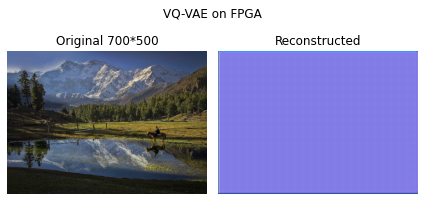

✅ 完成！结果保存至 result.png


In [12]:
# Cell 10: 显示结果
import matplotlib.pyplot as plt
import cv2

original  = cv2.resize(
    cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'img.png')), cv2.COLOR_BGR2RGB),
    (700,500))
    # cv2.cvtColor(cv2.imread(os.path.join(WORK_DIR,'test2.jpg')), cv2.COLOR_BGR2RGB),
    # (700,500))

recon = output[0] * 0.5 + 0.5
recon = np.clip(recon, 0.0, 1.0)
recon = (recon * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(original);  axes[0].set_title('Original 700*500'); axes[0].axis('off')
axes[1].imshow(recon);     axes[1].set_title('Reconstructed');  axes[1].axis('off')
plt.suptitle('VQ-VAE on FPGA', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result.png'), dpi=300)
plt.show()
print("✅ 完成！结果保存至 result.png")


图像质量评估（原图 vs 重建图）
   SSIM : 0.0447
   PSNR : 7.43 dB


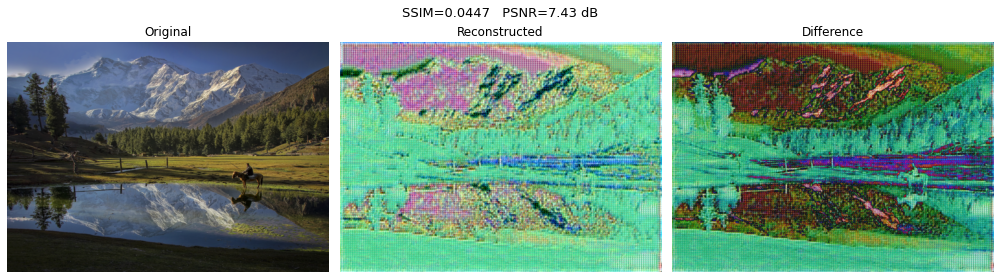

✅ 保存至 result_metrics.png


In [13]:
# Cell 11: 计算 SSIM 和 PSNR
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.metrics import structural_similarity as ssim_func

WORK_DIR = '/home/xilinx/jupyter_notebooks/duxu/pynq_vqvae'

# original：直接从送进 encoder 的 input_fp32 反归一化，和 main.py 完全一致
# input_fp32 shape=(1,500,700,3)，值域 [-1,1]
original = (input_fp32[0] * 0.5 + 0.5).clip(0.0, 1.0).astype(np.float32)  # [0,1]

# recon：DPU decoder 输出反归一化
# output shape=(1,500,700,3)，值域约 [-1,1]
recon = (output[0] * 0.5 + 0.5).clip(0.0, 1.0).astype(np.float32)         # [0,1]

ssim_val = ssim_func(original, recon, multichannel=True, data_range=2.0)
mse      = np.mean((original - recon) ** 2)
psnr_val = 20 * np.log10(1.0 / np.sqrt(mse + 1e-8))

print(f"\n图像质量评估（原图 vs 重建图）")
print(f"   SSIM : {ssim_val:.4f}")
print(f"   PSNR : {psnr_val:.2f} dB")

diff      = np.abs(original - recon)
diff_norm = (diff / (diff.max() + 1e-8) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(original);               axes[0].set_title('Original');      axes[0].axis('off')
axes[1].imshow(recon);                  axes[1].set_title('Reconstructed'); axes[1].axis('off')
axes[2].imshow(diff_norm, cmap='hot');  axes[2].set_title('Difference');    axes[2].axis('off')
plt.suptitle(f'SSIM={ssim_val:.4f}   PSNR={psnr_val:.2f} dB', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'result_metrics.png'), dpi=300)
plt.show()
print("✅ 保存至 result_metrics.png")